In [57]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

In [58]:
columns = [
    "duration", "protocol_type", "service", "flag", "src_bytes", "dst_bytes",
    "land", "wrong_fragment", "urgent", "hot", "num_failed_logins", "logged_in",
    "num_compromised", "root_shell", "su_attempted", "num_root", "num_file_creations",
    "num_shells", "num_access_files", "num_outbound_cmds", "is_host_login",
    "is_guest_login", "count", "srv_count", "serror_rate", "srv_serror_rate",
    "rerror_rate", "srv_rerror_rate", "same_srv_rate", "diff_srv_rate",
    "srv_diff_host_rate", "dst_host_count", "dst_host_srv_count",
    "dst_host_same_srv_rate", "dst_host_diff_srv_rate", "dst_host_same_src_port_rate",
    "dst_host_srv_diff_host_rate", "dst_host_serror_rate", "dst_host_srv_serror_rate",
    "dst_host_rerror_rate", "dst_host_srv_rerror_rate",
    "label", "difficulty"
]

In [59]:
df = pd.read_csv("nsl-kdd/KDDTrain+_20Percent.txt", header=None, names = columns)
print(df.shape)
print(df.head())

(25192, 43)
   duration protocol_type   service flag  src_bytes  dst_bytes  land  \
0         0           tcp  ftp_data   SF        491          0     0   
1         0           udp     other   SF        146          0     0   
2         0           tcp   private   S0          0          0     0   
3         0           tcp      http   SF        232       8153     0   
4         0           tcp      http   SF        199        420     0   

   wrong_fragment  urgent  hot  ...  dst_host_same_srv_rate  \
0               0       0    0  ...                    0.17   
1               0       0    0  ...                    0.00   
2               0       0    0  ...                    0.10   
3               0       0    0  ...                    1.00   
4               0       0    0  ...                    1.00   

   dst_host_diff_srv_rate  dst_host_same_src_port_rate  \
0                    0.03                         0.17   
1                    0.60                         0.88   
2 

In [60]:
# Identifying important features
print(df.dtypes)

duration                         int64
protocol_type                   object
service                         object
flag                            object
src_bytes                        int64
dst_bytes                        int64
land                             int64
wrong_fragment                   int64
urgent                           int64
hot                              int64
num_failed_logins                int64
logged_in                        int64
num_compromised                  int64
root_shell                       int64
su_attempted                     int64
num_root                         int64
num_file_creations               int64
num_shells                       int64
num_access_files                 int64
num_outbound_cmds                int64
is_host_login                    int64
is_guest_login                   int64
count                            int64
srv_count                        int64
serror_rate                    float64
srv_serror_rate          

In [43]:
y = (df["label"] != "normal").astype(int).values
print(f"Normal: {(y==0).sum()}, Attack: {(y==1).sum()}")

Normal: 13449, Attack: 11743


In [62]:
# # drop categorical columns
# df = df.drop(columns=["protocol_type", "service", "flag"])
# # Also drop label that is just output and difficulty, as it idts has any importance
# df = df.drop(columns=["label", "difficulty"])

# Combine
X = df.drop(columns=["difficulty", "label", "protocol_type", "service", "flag"])

In [63]:
print(X.dtypes)

duration                         int64
src_bytes                        int64
dst_bytes                        int64
land                             int64
wrong_fragment                   int64
urgent                           int64
hot                              int64
num_failed_logins                int64
logged_in                        int64
num_compromised                  int64
root_shell                       int64
su_attempted                     int64
num_root                         int64
num_file_creations               int64
num_shells                       int64
num_access_files                 int64
num_outbound_cmds                int64
is_host_login                    int64
is_guest_login                   int64
count                            int64
srv_count                        int64
serror_rate                    float64
srv_serror_rate                float64
rerror_rate                    float64
srv_rerror_rate                float64
same_srv_rate            

In [64]:
# Using small subset of Dataset 20%

X_small = X.sample(n=2000, random_state=42)

In [65]:
scalar = StandardScaler()
X_small_scaled = scalar.fit_transform(X_small)

print(X_small_scaled.shape)
print(X_small_scaled.mean(axis=0).round(2))
print(X_small_scaled.std(axis=0).round(2))

(2000, 38)
[ 0.  0.  0.  0.  0.  0.  0.  0. -0. -0.  0.  0. -0. -0.  0.  0.  0.  0.
  0.  0. -0.  0.  0.  0. -0. -0. -0. -0.  0. -0. -0. -0.  0. -0. -0.  0.
  0.  0.]
[1. 1. 1. 0. 1. 0. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 0. 0. 1. 1. 1. 1. 1. 1.
 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]


In [66]:
pca = PCA(n_components=0.90)
X_PCA = pca.fit_transform(X_small_scaled)
print(f"Original features : {X_small_scaled.shape[1]}")
print(f"After PCA         : {X_PCA.shape[1]}")
print(f"Variance explained: {sum(pca.explained_variance_ratio_):.3f}")


Original features : 38
After PCA         : 15
Variance explained: 0.909


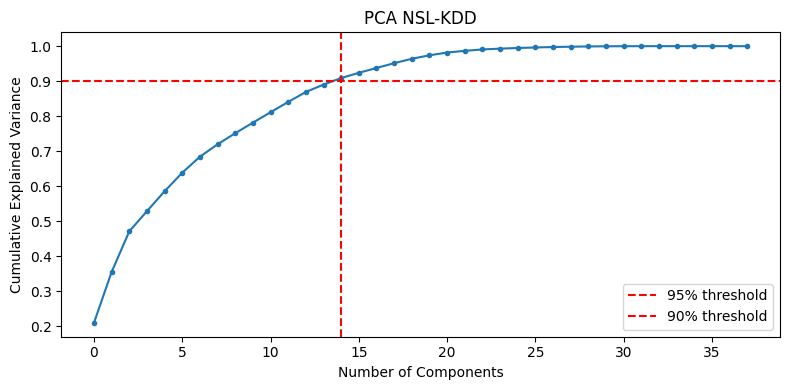

In [68]:
import matplotlib.pyplot as plt

pca_full = PCA().fit(X_small_scaled)
cumvar = np.cumsum(pca_full.explained_variance_ratio_)

plt.figure(figsize=(8, 4))
plt.plot(cumvar, marker='o', markersize=3)
plt.axhline(0.90, color='red', linestyle='--', label='95% threshold')
plt.axvline(14, color='red', linestyle='--', label='90% threshold')
plt.xlabel('Number of Components')
plt.ylabel('Cumulative Explained Variance')
plt.title('PCA NSL-KDD')
plt.legend()
plt.tight_layout()
plt.savefig('pca_variance.png')

In [83]:
# Around 14-15 features covers 90% variance, dropped other attributes
pc_cols = [f'PC{i+1}' for i in range(X_PCA.shape[1])]
X_PCA_df = pd.DataFrame(X_PCA, columns=pc_cols)

print(X_PCA_df.shape)   
print(X_PCA_df.dtypes)   
print(X_PCA_df.head())   

(2000, 15)
PC1     float64
PC2     float64
PC3     float64
PC4     float64
PC5     float64
PC6     float64
PC7     float64
PC8     float64
PC9     float64
PC10    float64
PC11    float64
PC12    float64
PC13    float64
PC14    float64
PC15    float64
dtype: object
        PC1       PC2       PC3       PC4       PC5       PC6       PC7  \
0  1.930299 -0.347082 -0.222747 -0.467283 -0.470352  0.363189  1.290255   
1  1.496589  4.076472 -0.347684  0.037019 -0.390536  0.099992 -1.213231   
2 -3.541047 -1.359618  0.176834 -0.017179  0.084155  0.343679 -0.343378   
3  1.213372 -0.154975 -0.102705 -0.032094  0.126400  0.944304 -0.051096   
4 -1.238222 -1.736354  0.116723 -0.117651 -0.051333  1.405144 -0.782094   

        PC8       PC9      PC10      PC11      PC12      PC13      PC14  \
0  0.564755 -0.363801 -0.018668  0.014007  0.009917 -0.533703 -0.139794   
1 -1.930721 -1.197025  0.200683  0.221514  0.040915  0.381695 -0.965141   
2 -0.002118 -0.295888  0.127057 -0.005751  0.023402 -0.1130

In [84]:
y_small = y[X_small.index]   # align labels to the 2000 sampled rows
print(f"X_PCA shape : {X_PCA.shape}")
print(f"y_small shape: {y_small.shape}")
print(f"Normal: {(y_small==0).sum()}, Attack: {(y_small==1).sum()}")


X_PCA shape : (2000, 15)
y_small shape: (2000,)
Normal: 1058, Attack: 942


In [85]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_PCA, y_small,
    test_size=0.2,
    random_state=42,
    stratify=y_small        # keeps class ratio balanced in both splits
)


In [86]:
print(f"Train: {X_train.shape}, Test: {X_test.shape}")

Train: (1600, 15), Test: (400, 15)


In [88]:
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset

X_train_t = torch.tensor(X_train, dtype=torch.float32)
X_test_t  = torch.tensor(X_test,  dtype=torch.float32)
y_train_t = torch.tensor(y_train, dtype=torch.float32).unsqueeze(1) 
y_test_t  = torch.tensor(y_test,  dtype=torch.float32).unsqueeze(1)
 
train_ds = TensorDataset(X_train_t, y_train_t)
test_ds  = TensorDataset(X_test_t,  y_test_t)
 
train_loader = DataLoader(train_ds, batch_size=64, shuffle=True)
test_loader  = DataLoader(test_ds,  batch_size=64, shuffle=False)


In [89]:
input_dim = X_train.shape[1]   # number of PCA components (~14-15)
 
class IntrusionDetector(nn.Module):
    def __init__(self, input_dim):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, 64),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(64, 32),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(32, 1),
            nn.Sigmoid()          # output: probability of attack
        )
 
    def forward(self, x):
        return self.net(x)
 
model = IntrusionDetector(input_dim)
print(model)
print(f"Total parameters: {sum(p.numel() for p in model.parameters())}")
 


IntrusionDetector(
  (net): Sequential(
    (0): Linear(in_features=15, out_features=64, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.3, inplace=False)
    (3): Linear(in_features=64, out_features=32, bias=True)
    (4): ReLU()
    (5): Dropout(p=0.2, inplace=False)
    (6): Linear(in_features=32, out_features=1, bias=True)
    (7): Sigmoid()
  )
)
Total parameters: 3137


In [90]:
device    = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model     = model.to(device)
criterion = nn.BCELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
 
print(f"Training on: {device}")


Training on: cpu


In [91]:
EPOCHS = 30
train_losses, val_losses = [], []
train_accs,   val_accs   = [], []


In [92]:
for epoch in range(EPOCHS):
    # ── Train ──
    model.train()
    total_loss, correct, total = 0, 0, 0
    for X_batch, y_batch in train_loader:
        X_batch, y_batch = X_batch.to(device), y_batch.to(device)
        optimizer.zero_grad()
        preds = model(X_batch)
        loss  = criterion(preds, y_batch)
        loss.backward()
        optimizer.step()
 
        total_loss += loss.item() * len(y_batch)
        correct    += ((preds >= 0.5).float() == y_batch).sum().item()
        total      += len(y_batch)
 
    train_losses.append(total_loss / total)
    train_accs.append(correct / total)
 
    # ── Validate ──
    model.eval()
    val_loss, val_correct, val_total = 0, 0, 0
    with torch.no_grad():
        for X_batch, y_batch in test_loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            preds    = model(X_batch)
            val_loss += criterion(preds, y_batch).item() * len(y_batch)
            val_correct += ((preds >= 0.5).float() == y_batch).sum().item()
            val_total   += len(y_batch)
 
    val_losses.append(val_loss / val_total)
    val_accs.append(val_correct / val_total)
 
    if (epoch + 1) % 5 == 0:
        print(f"Epoch {epoch+1:02d}/{EPOCHS} | "
              f"Train Loss: {train_losses[-1]:.4f}, Acc: {train_accs[-1]:.4f} | "
              f"Val Loss: {val_losses[-1]:.4f}, Acc: {val_accs[-1]:.4f}")


Epoch 05/30 | Train Loss: 0.1407, Acc: 0.9544 | Val Loss: 0.1791, Acc: 0.9450
Epoch 10/30 | Train Loss: 0.1090, Acc: 0.9644 | Val Loss: 0.1525, Acc: 0.9625
Epoch 15/30 | Train Loss: 0.0969, Acc: 0.9706 | Val Loss: 0.1443, Acc: 0.9650
Epoch 20/30 | Train Loss: 0.0948, Acc: 0.9681 | Val Loss: 0.1401, Acc: 0.9675
Epoch 25/30 | Train Loss: 0.0862, Acc: 0.9656 | Val Loss: 0.1374, Acc: 0.9675
Epoch 30/30 | Train Loss: 0.0788, Acc: 0.9669 | Val Loss: 0.1333, Acc: 0.9625


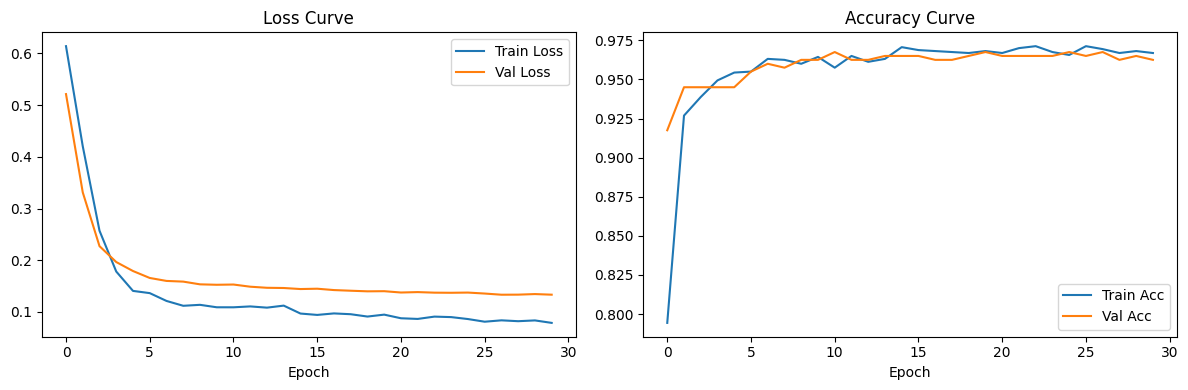

In [93]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
 
ax1.plot(train_losses, label='Train Loss')
ax1.plot(val_losses,   label='Val Loss')
ax1.set_title('Loss Curve')
ax1.set_xlabel('Epoch')
ax1.legend()
 
ax2.plot(train_accs, label='Train Acc')
ax2.plot(val_accs,   label='Val Acc')
ax2.set_title('Accuracy Curve')
ax2.set_xlabel('Epoch')
ax2.legend()
 
plt.tight_layout()
plt.savefig('training_curves_MLP.png')
plt.show()


In [95]:
from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix

model.eval()
all_preds, all_probs, all_labels = [], [], []
 
with torch.no_grad():
    for X_batch, y_batch in test_loader:
        X_batch = X_batch.to(device)
        probs   = model(X_batch).cpu().numpy()
        preds   = (probs >= 0.5).astype(int)
        all_probs.extend(probs.flatten())
        all_preds.extend(preds.flatten())
        all_labels.extend(y_batch.numpy().flatten())
 
all_preds  = np.array(all_preds)
all_labels = np.array(all_labels)
all_probs  = np.array(all_probs)
 
print("\n── Classification Report ──")
print(classification_report(all_labels, all_preds, target_names=["Normal", "Attack"]))
print(f"ROC-AUC Score: {roc_auc_score(all_labels, all_probs):.4f}")



── Classification Report ──
              precision    recall  f1-score   support

      Normal       0.94      0.99      0.97       212
      Attack       0.99      0.93      0.96       188

    accuracy                           0.96       400
   macro avg       0.97      0.96      0.96       400
weighted avg       0.96      0.96      0.96       400

ROC-AUC Score: 0.9848


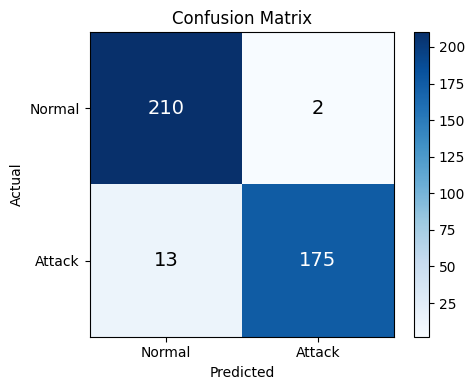

In [96]:
cm = confusion_matrix(all_labels, all_preds)
fig, ax = plt.subplots(figsize=(5, 4))
im = ax.imshow(cm, cmap='Blues')
ax.set_xticks([0, 1]); ax.set_yticks([0, 1])
ax.set_xticklabels(['Normal', 'Attack'])
ax.set_yticklabels(['Normal', 'Attack'])
ax.set_xlabel('Predicted'); ax.set_ylabel('Actual')
ax.set_title('Confusion Matrix')
for i in range(2):
    for j in range(2):
        ax.text(j, i, cm[i, j], ha='center', va='center',
                color='white' if cm[i, j] > cm.max()/2 else 'black', fontsize=14)
plt.colorbar(im)
plt.tight_layout()
plt.savefig('confusion_matrix_MLP.png')
plt.show()
